### Estimação do modelo de regressão logística para baixada de empresas

**Entrada:** `data/dataset_modelagem_final.parquet` (45.874 linhas, 47 colunas) -- checkpoint final dos notebooks 01-04, com todos os preditores já tratados.

**Saída:** `data/modelo_final_logit.pickle` (modelo ajustado), `data/df_modelo_treino.parquet` e `data/probs_treino.parquet` (base de treino e probabilidades previstas), usados nos notebooks seguintes.

#### 1. Carregamento dos dados

Carrega o dataset final de preditores e confere shape e colunas antes de montar a base de modelagem.

In [1]:
# statsmodels para a regressão logística e o stepwise; sklearn só para as métricas de ROC/AUC
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statstests.process import stepwise  # importado mas nao usado -- substituido pelo stepwise manual (seção 7)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score


In [2]:
# Carrega o dataset final de preditores (notebooks 01-04 já fecharam essa lista)
df = pd.read_parquet('../data/dataset_modelagem_final.parquet')

In [3]:
# shape e colunas esperadas apos os notebooks 01-04 (47 colunas: 44 originais + 3 derivadas)
print(df.shape)
print(list(df.columns))

(45874, 47)
['cnpj_basico', 'cnpj_ordem', 'cnpj_dv', 'identificador_matriz_filial', 'nome_fantasia', 'situacao_cadastral', 'data_situacao_cadastral', 'motivo_situacao_cadastral', 'nome_cidade_exterior', 'pais', 'data_inicio_atividade', 'cnae_fiscal_principal', 'cnae_fiscal_secundaria', 'tipo_logradouro', 'logradouro', 'numero', 'complemento', 'bairro', 'cep', 'uf', 'municipio', 'ddd1', 'telefone1', 'ddd2', 'telefone2', 'ddd_fax', 'fax', 'correio_eletronico', 'situacao_especial', 'data_situacao_especial', 'risco', 'razao_social', 'natureza_juridica', 'qualificacao_responsavel', 'capital_social', 'porte_empresa', 'ente_federativo_responsavel', 'optante_simples', 'data_opcao_simples', 'data_exclusao_simples', 'optante_mei', 'data_opcao_mei', 'data_exclusao_mei', 'alvo_baixada', 'natureza_juridica_agrupada', 'regiao', 'grupo_cnae']


#### 2. Seleção e preparação dos preditores

Recalcula `idade_empresa_anos` (não persistida no checkpoint final) e seleciona os preditores definidos nos notebooks 01-04 para a base de modelagem.

In [4]:
# Ajustes: alvo real é 'alvo_baixada'; idade_empresa_anos precisa ser recalculada
# (não veio persistida no dataset_modelagem_final.parquet, só a data bruta)

data_referencia = pd.Timestamp('2026-08-08')  # mesma referência da extração original dos dados

df['data_inicio_atividade'] = pd.to_datetime(df['data_inicio_atividade'], errors='coerce')
df['idade_empresa_anos'] = (data_referencia - df['data_inicio_atividade']).dt.days / 365.25

preditores = [
    'identificador_matriz_filial',
    'idade_empresa_anos',
    'capital_social',
    'porte_empresa',
    'natureza_juridica_agrupada',
    'regiao',
    'grupo_cnae',
]

cols_modelo = preditores + ['alvo_baixada']
df_modelo = df[cols_modelo].copy()
df_modelo = df_modelo.rename(columns={'alvo_baixada': 'alvo'})  # só pra facilitar a fórmula depois

print(df_modelo.shape)
print(df_modelo.dtypes)
print(df_modelo.isna().sum())
df_modelo.head()

(45874, 8)
identificador_matriz_filial        str
idade_empresa_anos             float64
capital_social                 float64
porte_empresa                      str
natureza_juridica_agrupada         str
regiao                             str
grupo_cnae                         str
alvo                             int64
dtype: object
identificador_matriz_filial    0
idade_empresa_anos             0
capital_social                 0
porte_empresa                  0
natureza_juridica_agrupada     0
regiao                         0
grupo_cnae                     0
alvo                           0
dtype: int64


,identificador_matriz_filial,idade_empresa_anos,capital_social,porte_empresa,natureza_juridica_agrupada,regiao,grupo_cnae,alvo
0,1,7.236140,30000.0,01,2062,Sul,478,0
1,1,9.171800,110000.0,01,2062,Sudeste,474,0
2,1,7.816564,5000.0,01,2135,Sudeste,472,0
3,1,7.408624,500.0,01,2135,Sul,474,0
4,1,9.029432,10000.0,01,2135,Sudeste,475,0


#### 3. Checagem exploratória dos preditores

Confere a distribuição de cada preditor (contagens, describe) antes de transformar e codificar, para não levar uma surpresa (ex.: `capital_social` com valores zerados) para a estimação sem perceber.

In [5]:
# checagem rapida de distribuicao de cada preditor antes de transformar/codificar -- confere
# cardinalidade das categoricas e possiveis valores estranhos nas numericas (ex.: capital_social <= 0)
for col in ['identificador_matriz_filial', 'porte_empresa', 'natureza_juridica_agrupada', 'regiao', 'grupo_cnae']:
    print(f"--- {col} ---")
    print(df_modelo[col].value_counts(dropna=False))
    print()

print("--- capital_social ---")
print(df_modelo['capital_social'].describe())
print("mínimo:", df_modelo['capital_social'].min())
print("valores <= 0:", (df_modelo['capital_social'] <= 0).sum())

print("--- idade_empresa_anos ---")
print(df_modelo['idade_empresa_anos'].describe())

print("--- alvo ---")
print(df_modelo['alvo'].value_counts(normalize=True))

--- identificador_matriz_filial ---
identificador_matriz_filial
1    43549
2     2325
Name: count, dtype: int64

--- porte_empresa ---
porte_empresa
01    43079
03     1763
05     1032
Name: count, dtype: int64

--- natureza_juridica_agrupada ---
natureza_juridica_agrupada
2135      37214
2062       8443
2054         99
2046         98
Outras       20
Name: count, dtype: int64

--- regiao ---
regiao
Sudeste         20995
Nordeste        10367
Sul              7564
Centro-Oeste     4138
Norte            2810
Name: count, dtype: int64

--- grupo_cnae ---
grupo_cnae
478    17856
472     8323
475     6156
471     4684
477     4063
474     2967
476     1547
473      278
Name: count, dtype: int64

--- capital_social ---
count    4.587400e+04
mean     2.041121e+07
std      4.889138e+08
min      0.000000e+00
25%      2.000000e+03
50%      5.000000e+03
75%      2.000000e+04
max      3.991828e+10
Name: capital_social, dtype: float64
mínimo: 0.0
valores <= 0: 44
--- idade_empresa_anos ---
count  

#### 4. Transformação de `capital_social`

Aplica log1p em `capital_social`: a variável é muito assimétrica e tem zeros, e log1p evita erro de log(0) e estabiliza a variância.

In [6]:
# log-transform do capital social (alta assimetria + zeros -> log1p)
df_modelo['capital_social_log'] = np.log1p(df_modelo['capital_social'])
df_modelo = df_modelo.drop(columns=['capital_social'])

#### 5. Codificação categórica

Converte as categóricas em dummies, fixando a categoria mais frequente de cada uma como referência (dropada), para que os coeficientes sejam interpretáveis em relação ao caso mais comum.

In [7]:
# Define a ordem de cada categórica com a categoria MAIS FREQUENTE primeiro,
# assim o drop_first do get_dummies dropa ela (fica como referência da interpretação)
ordem_categorias = {
    'identificador_matriz_filial': ['1', '2'],                                    # 1=Matriz (maioria)
    'porte_empresa': ['01', '03', '05'],                                          # 01=ME (maioria)
    'natureza_juridica_agrupada': ['2135', '2062', '2054', '2046', 'Outras'],     # 2135 maioria
    'regiao': ['Sudeste', 'Nordeste', 'Sul', 'Centro-Oeste', 'Norte'],            # Sudeste maioria
    'grupo_cnae': ['478', '472', '475', '471', '477', '474', '476', '473'],      # 478 maioria
}

for col, ordem in ordem_categorias.items():
    df_modelo[col] = pd.Categorical(df_modelo[col], categories=ordem, ordered=False)

df_dummies = pd.get_dummies(
    df_modelo,
    columns=list(ordem_categorias.keys()),
    drop_first=True,
    dtype=int,
)

print(df_dummies.shape)
print(df_dummies.columns.tolist())
df_dummies.head()

(45874, 21)
['idade_empresa_anos', 'alvo', 'capital_social_log', 'identificador_matriz_filial_2', 'porte_empresa_03', 'porte_empresa_05', 'natureza_juridica_agrupada_2062', 'natureza_juridica_agrupada_2054', 'natureza_juridica_agrupada_2046', 'natureza_juridica_agrupada_Outras', 'regiao_Nordeste', 'regiao_Sul', 'regiao_Centro-Oeste', 'regiao_Norte', 'grupo_cnae_472', 'grupo_cnae_475', 'grupo_cnae_471', 'grupo_cnae_477', 'grupo_cnae_474', 'grupo_cnae_476', 'grupo_cnae_473']


,idade_empresa_anos,alvo,capital_social_log,identificador_matriz_filial_2,porte_empresa_03,porte_empresa_05,natureza_juridica_agrupada_2062,natureza_juridica_agrupada_2054,natureza_juridica_agrupada_2046,natureza_juridica_agrupada_Outras,...,regiao_Sul,regiao_Centro-Oeste,regiao_Norte,grupo_cnae_472,grupo_cnae_475,grupo_cnae_471,grupo_cnae_477,grupo_cnae_474,grupo_cnae_476,grupo_cnae_473
0,7.236140,0,10.308986,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,9.171800,0,11.608245,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,7.816564,0,8.517393,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,7.408624,0,6.216606,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
4,9.029432,0,9.210440,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [8]:
# Ajuste de segurança: hífen no nome de coluna quebra a fórmula do patsy
df_dummies.columns = df_dummies.columns.str.replace('-', '_', regex=False)

#### 6. Estimação do modelo completo

Ajusta a regressão logística com todos os preditores, usando uma fórmula montada automaticamente a partir das colunas para não digitar (e errar) 20 nomes na mão.

In [9]:
# Monta a fórmula automaticamente a partir de todas as colunas exceto o alvo
# (evita digitar 20 nomes de variável na mão e errar algum)
preditores_dummies = [c for c in df_dummies.columns if c != 'alvo']
formula = 'alvo ~ ' + ' + '.join(preditores_dummies)
print(formula)

modelo_completo = sm.Logit.from_formula(formula, data=df_dummies).fit()
print(modelo_completo.summary())

alvo ~ idade_empresa_anos + capital_social_log + identificador_matriz_filial_2 + porte_empresa_03 + porte_empresa_05 + natureza_juridica_agrupada_2062 + natureza_juridica_agrupada_2054 + natureza_juridica_agrupada_2046 + natureza_juridica_agrupada_Outras + regiao_Nordeste + regiao_Sul + regiao_Centro_Oeste + regiao_Norte + grupo_cnae_472 + grupo_cnae_475 + grupo_cnae_471 + grupo_cnae_477 + grupo_cnae_474 + grupo_cnae_476 + grupo_cnae_473


Optimization terminated successfully.
         Current function value: 0.634462
         Iterations 6


                           Logit Regression Results                           
Dep. Variable:                   alvo   No. Observations:                45874
Model:                          Logit   Df Residuals:                    45853
Method:                           MLE   Df Model:                           20
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:                 0.06250
Time:                        16:08:41   Log-Likelihood:                -29105.
converged:                       True   LL-Null:                       -31046.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -0.2408      0.103     -2.333      0.020      -0.443      -0.038
idade_empresa_anos                    0.1864      0.012     16

#### 7. Seleção de variáveis (stepwise manual)

Implementa o backward elimination manualmente porque a função `stepwise` da biblioteca `statstests` entrou em loop infinito neste ambiente, descartando a mesma variável repetidamente sem atualizar a log-verossimilhança.

In [10]:
# Stepwise manual (backward elimination por teste de Wald).
# Substitui statstests.process.stepwise, que travou em loop infinito
# neste ambiente (descartava a mesma variável repetidamente sem
# de fato atualizar o modelo - log-verossimilhança idêntica a cada ciclo).
# ---------------------------------------------------------
def stepwise_manual(formula_base, data, pvalue_limit=0.05, verbose=True):
    formula_atual = formula_base
    while True:
        modelo = sm.Logit.from_formula(formula_atual, data=data).fit(disp=0)
        pvalues = modelo.pvalues.drop('Intercept')
        pior_pvalue = pvalues.max()

        if pior_pvalue <= pvalue_limit:
            break

        variavel_remover = pvalues.idxmax()
        if verbose:
            print(f"Removendo '{variavel_remover}' (p-valor = {pior_pvalue:.4f})")

        preditores_restantes = [v for v in pvalues.index if v != variavel_remover]
        formula_atual = 'alvo ~ ' + ' + '.join(preditores_restantes)

    return modelo, formula_atual


modelo_step, formula_final = stepwise_manual(formula, df_dummies, pvalue_limit=0.05)

print("\n" + "="*70)
print("Fórmula final após o Stepwise:")
print(formula_final)
print("="*70 + "\n")
print(modelo_step.summary())

Removendo 'regiao_Norte' (p-valor = 0.2457)


Removendo 'regiao_Sul' (p-valor = 0.1302)



Fórmula final após o Stepwise:
alvo ~ idade_empresa_anos + capital_social_log + identificador_matriz_filial_2 + porte_empresa_03 + porte_empresa_05 + natureza_juridica_agrupada_2062 + natureza_juridica_agrupada_2054 + natureza_juridica_agrupada_2046 + natureza_juridica_agrupada_Outras + regiao_Nordeste + regiao_Centro_Oeste + grupo_cnae_472 + grupo_cnae_475 + grupo_cnae_471 + grupo_cnae_477 + grupo_cnae_474 + grupo_cnae_476 + grupo_cnae_473

                           Logit Regression Results                           
Dep. Variable:                   alvo   No. Observations:                45874
Model:                          Logit   Df Residuals:                    45855
Method:                           MLE   Df Model:                           18
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:                 0.06244
Time:                        16:08:43   Log-Likelihood:                -29107.
converged:                       True   LL-Null:                       -31046.


#### 8. Avaliação: matriz de confusão

Classifica com cutoff de 0,5 e calcula sensibilidade, especificidade e acurácia para um primeiro diagnóstico de desempenho.

In [11]:
# classifica como "vai fracassar" quando a probabilidade prevista passa de 50% -- cutoff padrão,
# so para uma primeira leitura (o trade-off por cutoff e explorado na proxima celula)
df_dummies['prob_predita'] = modelo_step.predict()

cutoff = 0.5
df_dummies['classificacao_predita'] = (df_dummies['prob_predita'] >= cutoff).astype(int)

matriz_confusao = pd.crosstab(
    df_dummies['alvo'], df_dummies['classificacao_predita'],
    rownames=['Real'], colnames=['Predito']
)
print(f"Matriz de confusão (cutoff = {cutoff}):")
print(matriz_confusao)

VN, FP = matriz_confusao.loc[0, 0], matriz_confusao.loc[0, 1]
FN, VP = matriz_confusao.loc[1, 0], matriz_confusao.loc[1, 1]

sensitividade = VP / (VP + FN)
especificidade = VN / (VN + FP)
acuracia = (VP + VN) / (VP + VN + FP + FN)

print(f"\nSensitividade (acerto entre os baixados de verdade): {sensitividade:.4f}")
print(f"Especificidade (acerto entre os ativos de verdade): {especificidade:.4f}")
print(f"Acurácia geral: {acuracia:.4f}")

Matriz de confusão (cutoff = 0.5):
Predito     0      1
Real                
0        5676  13120
1        2609  24469

Sensitividade (acerto entre os baixados de verdade): 0.9036
Especificidade (acerto entre os ativos de verdade): 0.3020
Acurácia geral: 0.6571


#### 9. Avaliação: sensibilidade × especificidade por cutoff

Varre cutoffs de 0,1 a 0,9 para visualizar o trade-off entre sensibilidade e especificidade e apoiar a escolha de um cutoff diferente de 0,5, se necessário.

    cutoff  sensitividade  especificidade
0     0.10       1.000000        0.000106
1     0.15       0.999298        0.005161
2     0.20       0.997119        0.022292
3     0.25       0.989032        0.065227
4     0.30       0.968979        0.139870
5     0.35       0.944641        0.214939
6     0.40       0.927321        0.260481
7     0.45       0.918052        0.280006
8     0.50       0.903649        0.301979
9     0.55       0.866571        0.345446
10    0.60       0.742115        0.480155
11    0.65       0.473816        0.713396
12    0.70       0.191853        0.894605
13    0.75       0.049561        0.972654
14    0.80       0.018207        0.989998
15    0.85       0.003250        0.998510
16    0.90       0.000406        0.999734


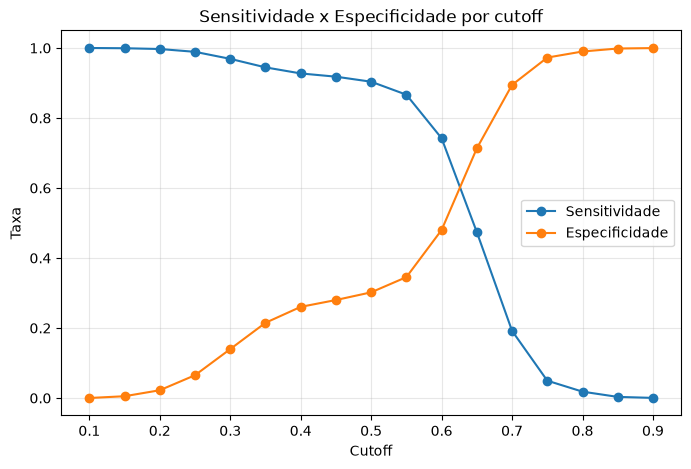

In [12]:
# varre cutoffs para visualizar o trade-off sensibilidade x especificidade -- ajuda a decidir se
# vale usar um cutoff diferente de 0.5 dependendo do custo de falso positivo vs. falso negativo
cutoffs = np.arange(0.1, 0.91, 0.05)
resultados = []

for c in cutoffs:
    pred = (df_dummies['prob_predita'] >= c).astype(int)
    matriz = pd.crosstab(df_dummies['alvo'], pred)
    VN = matriz.loc[0, 0] if 0 in matriz.columns else 0
    FP = matriz.loc[0, 1] if 1 in matriz.columns else 0
    FN = matriz.loc[1, 0] if 0 in matriz.columns else 0
    VP = matriz.loc[1, 1] if 1 in matriz.columns else 0
    sens = VP / (VP + FN) if (VP + FN) > 0 else np.nan
    espec = VN / (VN + FP) if (VN + FP) > 0 else np.nan
    resultados.append({'cutoff': round(c, 2), 'sensitividade': sens, 'especificidade': espec})

df_cutoffs = pd.DataFrame(resultados)
print(df_cutoffs)

plt.figure(figsize=(8, 5))
plt.plot(df_cutoffs['cutoff'], df_cutoffs['sensitividade'], marker='o', label='Sensitividade')
plt.plot(df_cutoffs['cutoff'], df_cutoffs['especificidade'], marker='o', label='Especificidade')
plt.xlabel('Cutoff')
plt.ylabel('Taxa')
plt.title('Sensitividade x Especificidade por cutoff')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("../outputs/sensitividade_especificidade_cutoff.png", dpi=150, bbox_inches="tight")
plt.show()

#### 10. Avaliação: curva ROC e AUC/GINI

Calcula a curva ROC, a AUC e o coeficiente de GINI (2×AUC-1), métricas de discriminação que não dependem da escolha de um cutoff específico.

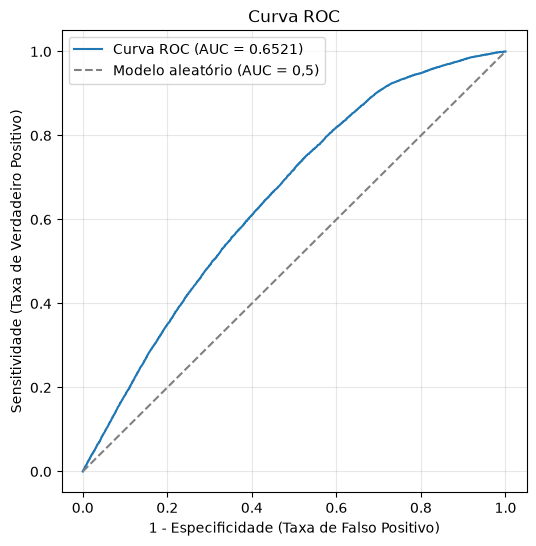

AUC: 0.6521
GINI: 0.3042


In [13]:
# curva ROC/AUC/GINI: mede a capacidade de discriminação do modelo independente de qualquer cutoff
fpr, tpr, thresholds = roc_curve(df_dummies['alvo'], df_dummies['prob_predita'])
auc = roc_auc_score(df_dummies['alvo'], df_dummies['prob_predita'])
gini = 2 * auc - 1

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatório (AUC = 0,5)')
plt.xlabel('1 - Especificidade (Taxa de Falso Positivo)')
plt.ylabel('Sensitividade (Taxa de Verdadeiro Positivo)')
plt.title('Curva ROC')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("../outputs/curva_roc.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"AUC: {auc:.4f}")
print(f"GINI: {gini:.4f}")

#### 11. Prévia do dataset de robustez (INAPTA)

Carrega o dataset dos casos excluídos do alvo original (situação INAPTA) só para conferir shape e colunas -- a análise de robustez em si é feita no notebook 06.

In [14]:
# só confere shape/colunas do dataset dos casos INAPTA (excluídos do alvo original) -- a análise de
# robustez com esse dataset é feita no notebook 06, aqui é só uma prévia antes de seguir
df_robustez = pd.read_parquet('../data/dataset_excluidos_robustez.parquet')

print(df_robustez.shape)
print(list(df_robustez.columns))
df_robustez.head()

(12822, 43)
['cnpj_basico', 'cnpj_ordem', 'cnpj_dv', 'identificador_matriz_filial', 'nome_fantasia', 'situacao_cadastral', 'data_situacao_cadastral', 'motivo_situacao_cadastral', 'nome_cidade_exterior', 'pais', 'data_inicio_atividade', 'cnae_fiscal_principal', 'cnae_fiscal_secundaria', 'tipo_logradouro', 'logradouro', 'numero', 'complemento', 'bairro', 'cep', 'uf', 'municipio', 'ddd1', 'telefone1', 'ddd2', 'telefone2', 'ddd_fax', 'fax', 'correio_eletronico', 'situacao_especial', 'data_situacao_especial', 'risco', 'razao_social', 'natureza_juridica', 'qualificacao_responsavel', 'capital_social', 'porte_empresa', 'ente_federativo_responsavel', 'optante_simples', 'data_opcao_simples', 'data_exclusao_simples', 'optante_mei', 'data_opcao_mei', 'data_exclusao_mei']


,cnpj_basico,cnpj_ordem,cnpj_dv,identificador_matriz_filial,nome_fantasia,situacao_cadastral,data_situacao_cadastral,motivo_situacao_cadastral,nome_cidade_exterior,pais,...,qualificacao_responsavel,capital_social,porte_empresa,ente_federativo_responsavel,optante_simples,data_opcao_simples,data_exclusao_simples,optante_mei,data_opcao_mei,data_exclusao_mei
0,34141380,0001,04,1,NaN,04,20220126,63,NaN,NaN,...,50,5000.0,01,NaN,True,20190708,00000000,True,20190708,00000000
1,35448551,0001,05,1,NaN,04,20210407,63,NaN,NaN,...,50,35000.0,01,NaN,True,20191107,00000000,False,20191107,20191130
2,29110289,0001,83,1,NaN,04,20221128,63,NaN,NaN,...,50,5800.0,01,NaN,True,20171121,00000000,True,20171121,00000000
3,32318795,0001,77,1,NaN,04,20220112,63,NaN,NaN,...,50,1000.0,01,NaN,True,20181227,00000000,True,20181227,00000000
4,32566875,0001,41,1,NaN,04,20220107,63,NaN,NaN,...,50,100.0,01,NaN,True,20190125,00000000,True,20190125,00000000


#### 12. Persistência de artefatos para os próximos notebooks

Salva o modelo ajustado, as probabilidades previstas no treino e a base de modelagem, para reuso nos notebooks seguintes sem precisar re-treinar.

In [15]:
# Persistência do modelo final (Stepwise manual, 18 preditores) para uso em outros notebooks
modelo_step.save('../data/modelo_final_logit.pickle')

In [16]:
# recalcula a probabilidade prevista no próprio treino, separada por classe real, para conferir se o
# modelo de fato separa ativas de baixadas (médias e quartis bem diferentes = bom sinal)
df_dummies["prob_baixada_prevista"] = modelo_step.predict(df_dummies)

prob_ativas = df_dummies.loc[df_dummies["alvo"] == 0, "prob_baixada_prevista"]
prob_baixadas = df_dummies.loc[df_dummies["alvo"] == 1, "prob_baixada_prevista"]

print("Empresas ATIVAS (alvo=0):")
print(prob_ativas.describe())

print("\nEmpresas BAIXADAS (alvo=1):")
print(prob_baixadas.describe())

Empresas ATIVAS (alvo=0):
count    18796.000000
mean         0.540783
std          0.164858
min          0.085654
25%          0.385078
50%          0.605276
75%          0.658227
max          0.932579
Name: prob_baixada_prevista, dtype: float64

Empresas BAIXADAS (alvo=1):
count    27078.000000
mean         0.624619
std          0.111575
min          0.106156
25%          0.598098
50%          0.645759
75%          0.688762
max          0.936826
Name: prob_baixada_prevista, dtype: float64


In [17]:
# salva alvo real + probabilidade prevista no treino, para uso nas análises de robustez/comparação (notebook 06)
df_dummies[["alvo", "prob_baixada_prevista"]].to_parquet("../data/probs_treino.parquet", index=False)
print("Salvo.")

Salvo.


In [18]:
# confirma que df_modelo está no estado esperado (8 colunas: 7 preditores + alvo) antes de persistir
print(df_modelo.columns.tolist())
print(df_modelo.shape)

['identificador_matriz_filial', 'idade_empresa_anos', 'porte_empresa', 'natureza_juridica_agrupada', 'regiao', 'grupo_cnae', 'alvo', 'capital_social_log']
(45874, 8)


In [19]:
# salva a base de modelagem (preditores + alvo, antes dos dummies) para reuso nos próximos notebooks
df_modelo.to_parquet("../data/df_modelo_treino.parquet", index=False)
print("Salvo.")

Salvo.
